<a href="https://colab.research.google.com/github/sadbinsiddique/Dl-net/blob/main/notebook/3.%20Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Training with **Colab**

<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; padding: 20px;">
    <div style="display: flex; gap: 12px; align-items: center; justify-content: center; flex-wrap: wrap;">
        <a href="https://colab.research.google.com/github/sadbinsiddique/Dl-net/blob/main/notebook/3.%20Train.ipynb" target="_blank" style="display: inline-flex; align-items: center; justify-content: center; gap: 6px; padding: 8px 16px; background: rgba(255, 255, 255, 0.15); backdrop-filter: blur(12px); -webkit-backdrop-filter: blur(12px); color: white; border-radius: 12px; text-decoration: none; font-weight: 600; font-size: 13px; border: 1px solid rgba(255, 255, 255, 0.25); cursor: pointer; transition: all 0.3s ease;">
            <img src="https://github.com/sadbinsiddique/Dl-net/blob/main/public/google-colab.svg?raw=1" alt="Online" style="width: 20px; height: 20px;">
            Google Colab
        </a>
        <a href="https://github.com/settings/tokens" target="_blank" style="display: inline-flex; align-items: center; justify-content: center; gap: 6px; padding: 8px 16px; background: rgba(255, 255, 255, 0.15); backdrop-filter: blur(12px); -webkit-backdrop-filter: blur(12px); color: white; border-radius: 12px; text-decoration: none; font-weight: 600; font-size: 13px; border: 1px solid rgba(255, 255, 255, 0.25); cursor: pointer; transition: all 0.3s ease;">
            <img src="https://github.com/sadbinsiddique/Dl-net/blob/main/public/github.png?raw=1" alt="Active" style="width: 20px; height: 20px;">
            Access Token
        </a>
    </div>
</div>

In [43]:
!pip install imagehash dotenv

In [44]:
import os
import torch
import importlib
import pandas as pd
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import torch.optim as optim
from getpass import getpass
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Cloud-Base Environment: {IN_COLAB}")

if IN_COLAB:
    env="colab"
    DATA_PATH = '/content/Dl-net/data/'
    token = getpass('Enter GitHub Access Token: ')
    !git clone https://{token}@github.com/sadbinsiddique/Dl-net.git
    os.chdir('/content/Dl-net')
else:
    env="local"
    DATA_PATH = './'
    print("Local environment detected. \nSkipping git clone.")

Cloud-Base Environment: True
Enter GitHub Access Token: ··········
fatal: destination path 'Dl-net' already exists and is not an empty directory.


++++++++++++++++++++++++++++++++++++++++++++++++++
Step 01: [data init]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Dataset: data/casme2-preprocessed-v2
[2]Dataset: data/ckplusferdata
[3]Dataset: data/sammassamexpression
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/ckplusferdata
[2]Found 35890 total files.


> Extracting Metadata: 100%|██████████| 35890/35890 [00:04<00:00, 7937.98it/s]


[4]Valid images: 35887 | Corrupted: 3


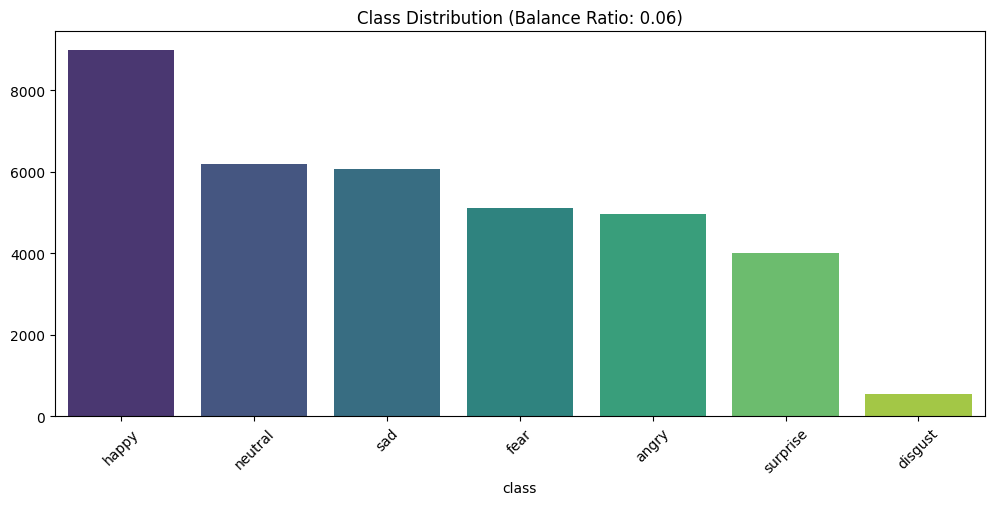

[5]Calculating image metrics...


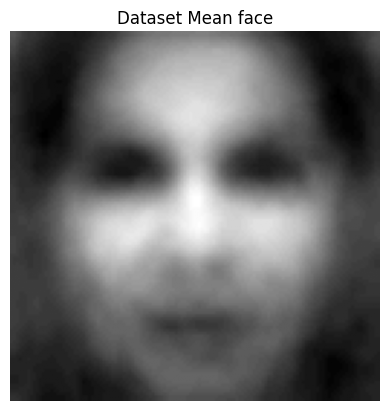

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 12965.75it/s]


[7]Running t-SNE...


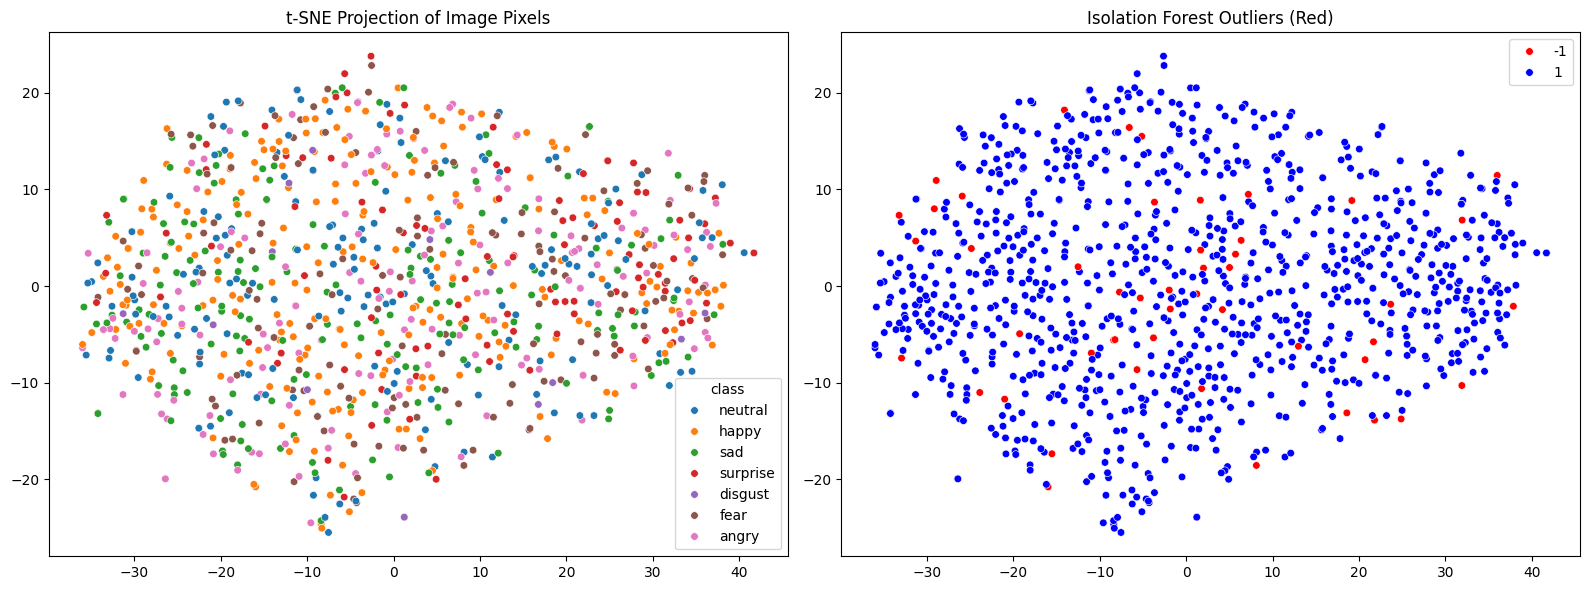

[8]./data/ckplusferdata/eda.csv saved successfully.
[9]EDA for ckplus saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64

Middle Sample Size: 5121
BALANCED CLASS DISTRIBUTION
class
angry       5121
disgust     5121
fear        5121
happy       5121
neutral     5121
sad         5121
surprise    5121
Name: count, dtype: int64

Balanced Dataset Shape: (35847, 14)
Train Shape : (28709, 14)
Test Shape  : (7178, 14)
[10]Data Balance for ckplus saved successfully.
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/sammassamexpression
[2]Found 23568 total files.


> Extracting Metadata: 100%|██████████| 23568/23568 [00:04<00:00, 5550.85it/s]


[4]Valid images: 23565 | Corrupted: 3


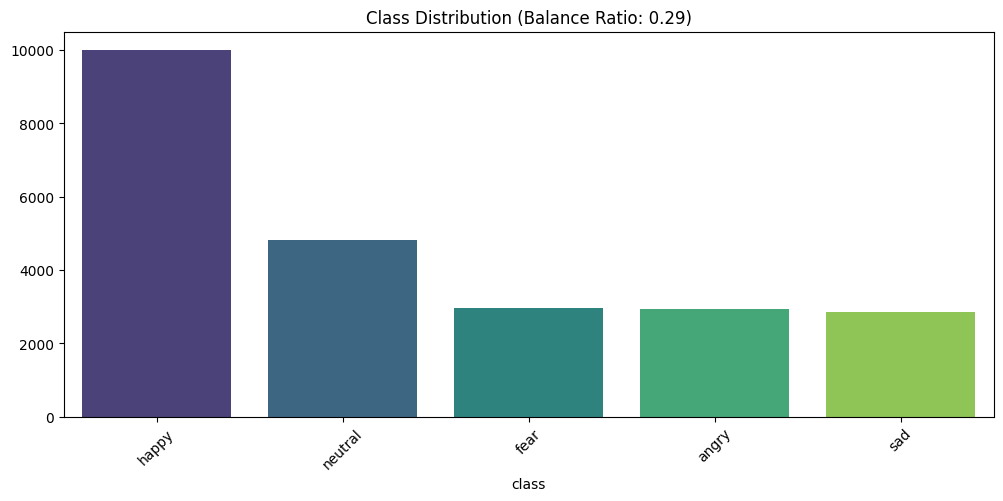

[5]Calculating image metrics...


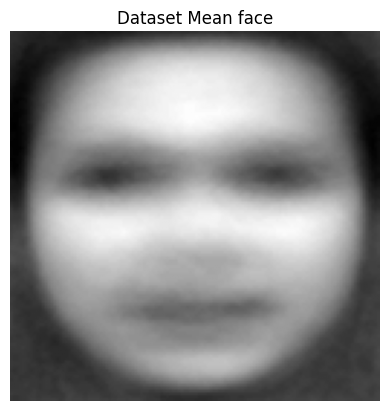

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 3744.11it/s]


[7]Running t-SNE...


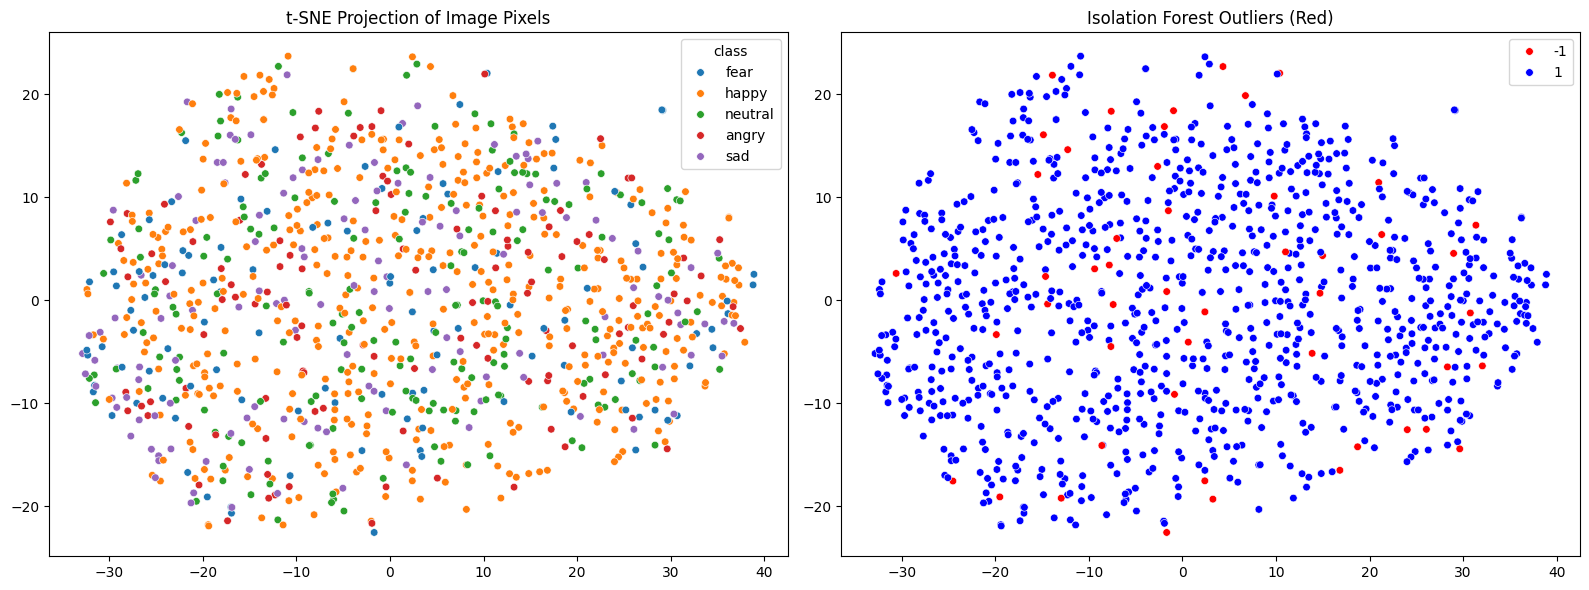

[8]./data/sammassamexpression/eda.csv saved successfully.
[9]EDA for samm saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       2940
fear        2954
happy      10001
neutral     4815
sad         2855
Name: count, dtype: int64

Middle Sample Size: 2954
BALANCED CLASS DISTRIBUTION
class
angry      2954
fear       2954
happy      2954
neutral    2954
sad        2954
Name: count, dtype: int64

Balanced Dataset Shape: (14770, 14)
Train Shape : (18852, 14)
Test Shape  : (4713, 14)
[10]Data Balance for samm saved successfully.
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/casme2-preprocessed-v2
[2]Found 17022 total files.


> Extracting Metadata: 100%|██████████| 17022/17022 [00:02<00:00, 7322.27it/s]


[4]Valid images: 17019 | Corrupted: 3


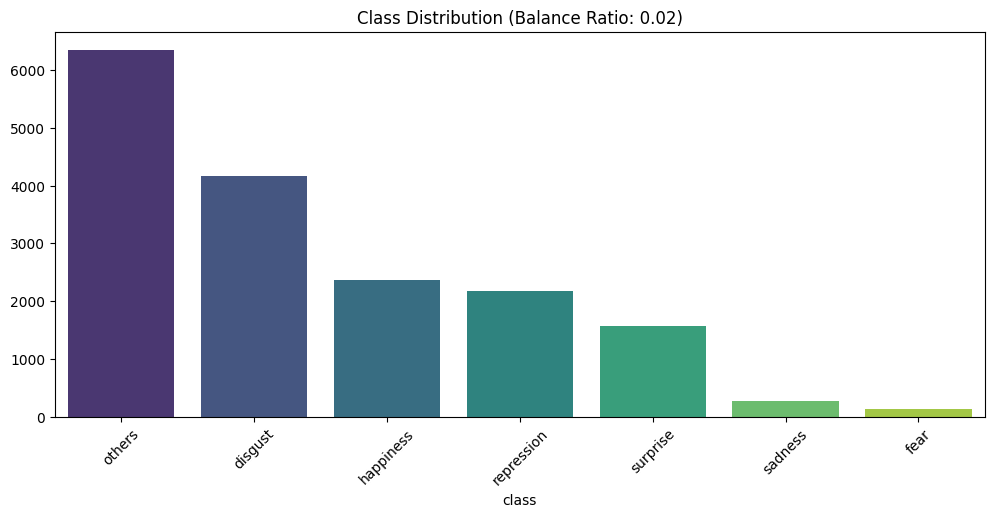

[5]Calculating image metrics...


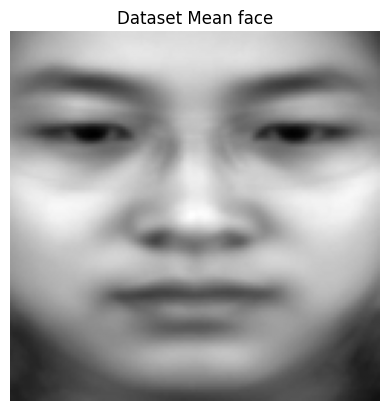

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 1802.59it/s]


[7]Running t-SNE...


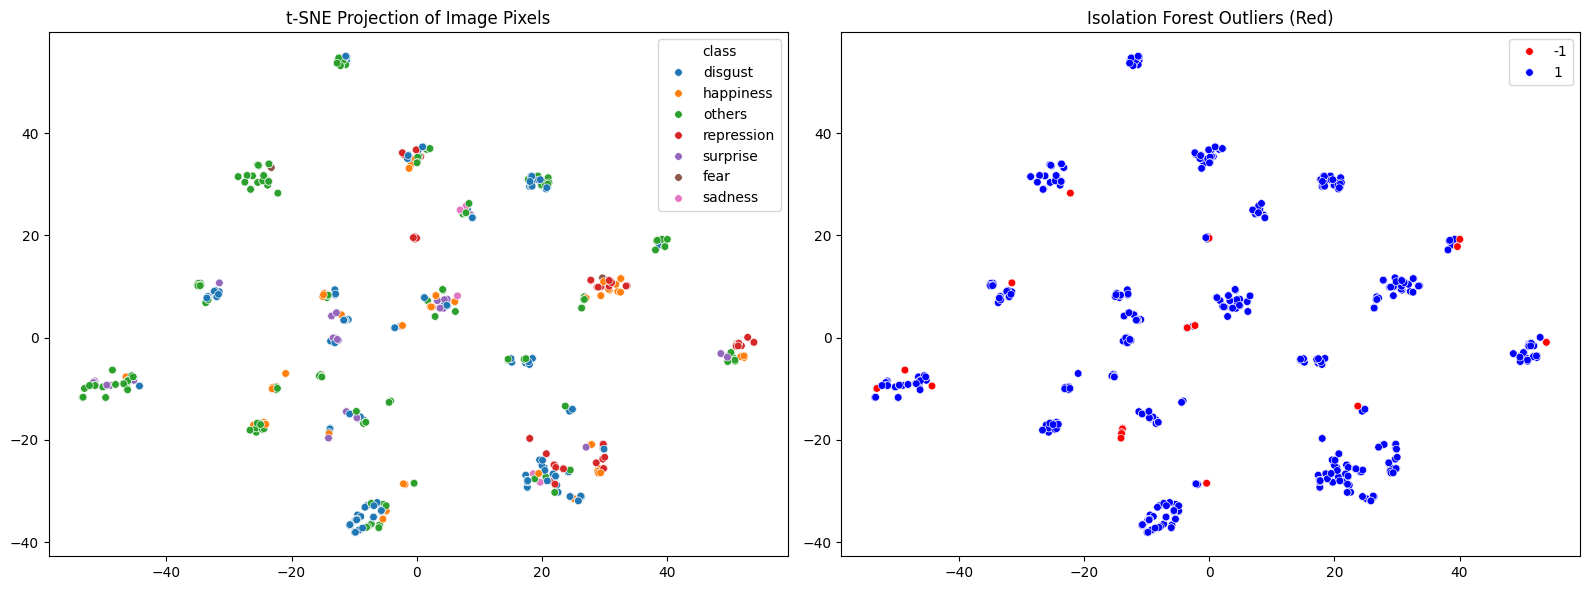

[8]./data/casme2-preprocessed-v2/eda.csv saved successfully.
[9]EDA for casme2 saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       2178
disgust     4159
fear         127
happy       2360
neutral     6344
sad          274
surprise    1577
Name: count, dtype: int64

Middle Sample Size: 2178
BALANCED CLASS DISTRIBUTION
class
angry       2178
disgust     2178
fear        2178
happy       2178
neutral     2178
sad         2178
surprise    2178
Name: count, dtype: int64

Balanced Dataset Shape: (15246, 14)
Train Shape : (13615, 14)
Test Shape  : (3404, 14)
[10]Data Balance for casme2 saved successfully.


In [45]:
!sed -i 's/^from eda import \*/from .eda import \*/' /content/Dl-net/src/utils/eda_imp.py

from src.utils import pipeline
importlib.reload(pipeline)
from src.utils.pipeline import _run_pipeline
_run_pipeline()

### Main Cord Start

In [46]:
data_no = getpass('Data No: ')
from pandas import pandas as pd

if int(data_no) == 1:
  train_df = pd.read_csv("/content/Dl-net/data/casme2-preprocessed-v2/train.csv")
  test_df = pd.read_csv("/content/Dl-net/data/casme2-preprocessed-v2/test.csv")
else:
  csv_path_train = ""
  csv_path_test = ""

test = test_df[["filepath","class"]]
train = train_df[["filepath","class"]]

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on training data and transform both train and test 'class' columns
train['class'] = label_encoder.fit_transform(train['class'])
test['class'] = label_encoder.transform(test['class'])

# Store class names and the number of classes globally
CLASS_NAMES = label_encoder.classes_
NUM_CLASSES_GLOBAL = len(CLASS_NAMES)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Encoded Classes: {CLASS_NAMES}")
print(f"Number of Classes: {NUM_CLASSES_GLOBAL}")

Data No: ··········
Train shape: (13615, 2)
Test shape: (3404, 2)
Encoded Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
Number of Classes: 7


In [47]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [48]:
from torch.utils.data import Dataset
from PIL import Image

class EmotionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image = Image.open(
            self.df.loc[idx,"filepath"]
        ).convert("RGB")

        label = int(self.df.loc[idx,"class"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [49]:
from torch.utils.data import DataLoader

train_dataset = EmotionDataset(train, train_transform)
val_dataset = EmotionDataset(test, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

## Alex Net


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Use the globally defined number of classes
num_classes = NUM_CLASSES_GLOBAL

model.classifier[6] = nn.Linear(
    4096,
    num_classes
)

model = model.to(device)

In [51]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
from tqdm import tqdm

epochs = 20

for epoch in range(epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    print(
        f"Epoch {epoch+1} | "
        f"Loss={train_loss/len(train_loader):.4f} | "
        f"Accuracy={100*correct/total:.2f}%"
    )

Epoch 1: 100%|██████████| 426/426 [00:50<00:00,  8.52it/s, acc=65.7, loss=0.769]


Epoch 1 | Loss=0.8669 | Accuracy=65.68%


Epoch 2: 100%|██████████| 426/426 [00:47<00:00,  8.97it/s, acc=87.3, loss=0.362]


Epoch 2 | Loss=0.3349 | Accuracy=87.34%


Epoch 3: 100%|██████████| 426/426 [00:49<00:00,  8.64it/s, acc=92.8, loss=0.0964]


...

Epoch 6: 100%|██████████| 426/426 [00:50<00:00,  8.51it/s, acc=97, loss=0.0596]


Epoch 6 | Loss=0.0810 | Accuracy=96.98%


Epoch 7: 100%|██████████| 426/426 [00:50<00:00,  8.48it/s, acc=97.4, loss=0.0188]


Epoch 7 | Loss=0.0713 | Accuracy=97.38%


Epoch 8:  67%|██████▋   | 285/426 [00:33<00:13, 10.11it/s, acc=97.7, loss=0.156]